# 39 - Larger-Cluster Within-Subtype Evaluation

Repeat the unlearning evaluation protocol with larger clusters that have enough
unseen cells for stable within-subtype matching.

**PBMC cluster 7** (CD14+ monocytes, 477 total, 80 unseen): forget 50 and 100 random cells
**TM cluster 28** (394 total, 67 unseen): forget 50 and 100 random cells

For each: train a retrain model excluding the forget subset, evaluate with
cross-cluster and within-cluster matching using 70-dim canonical features (v1 + kNN).

**Source:** `src/vae.py`, `src/train.py`, `src/attacker.py`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import torch.optim as optim
import json
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from sklearn.neighbors import NearestNeighbors

from utils import set_global_seed, GLOBAL_SEED, DEVICE
from vae import VAE, vae_loss
from train import create_dataloader, train_epoch, get_kl_weight
from attacker import (MLPAttacker, extract_vae_features, build_attack_features,
                      compute_knn_distances)
from attacker_eval import matched_negative_evaluation, compute_confidence_interval

set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('../outputs/larger_cluster_eval')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

2026-04-11 01:11:38.865797: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Helper functions

In [2]:
def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE)
    mc = {k: v for k, v in ckpt['config'].items()
          if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}
    model = VAE(**mc).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt['config']

def get_latent(model, X_array, device):
    model.eval()
    x = torch.FloatTensor(X_array).to(device)
    with torch.no_grad():
        mu, logvar = model.encode(x)
        z = model.reparameterize(mu, logvar)
    return z.cpu().numpy()

def get_70dim_features(model, X_array, retain_z, device):
    x = torch.FloatTensor(X_array).to(device)
    lib = x.sum(dim=1, keepdim=True)
    vae_feats = extract_vae_features(model, x, lib, device, requires_grad=False)
    query_z = vae_feats['z'].numpy()
    knn_dist = compute_knn_distances(query_z, retain_z, k=5)
    return build_attack_features(vae_feats, knn_dist_retain=knn_dist, variant='v1')

def train_fresh_attacker_70dim(pos_feats, neg_feats, device, seed=42):
    torch.manual_seed(seed)
    dim = pos_feats.shape[1]
    attacker = MLPAttacker(dim, [256, 256], dropout=0.3, use_spectral_norm=True).to(device)
    opt = optim.Adam(attacker.parameters(), lr=1e-3, weight_decay=1e-4)
    X = torch.cat([pos_feats, neg_feats]).to(device)
    y = torch.cat([torch.ones(len(pos_feats)),
                   torch.zeros(len(neg_feats))]).unsqueeze(1).to(device)
    for _ in range(100):
        attacker.train()
        opt.zero_grad()
        loss = torch.nn.functional.binary_cross_entropy_with_logits(attacker(X), y)
        loss.backward()
        opt.step()
    attacker.eval()
    metrics = matched_negative_evaluation(attacker, pos_feats, neg_feats, device=device)
    auc = metrics['auc']
    ci = compute_confidence_interval(
        torch.sigmoid(attacker(X.to(device))).detach().cpu().numpy().flatten(),
        y.cpu().numpy().flatten()
    )
    return {
        'auc': float(auc),
        'advantage': float(2 * abs(auc - 0.5)),
        'auc_ci': (float(ci['auc'][1]), float(ci['auc'][2])),
        'advantage_ci': (float(ci['advantage'][1]), float(ci['advantage'][2])),
    }

def train_retrain_model(adata, X_array, exclude_indices, config, device, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    all_train = set(range(len(X_array)))
    retain = sorted(all_train - set(exclude_indices))
    X_retain = torch.FloatTensor(X_array[retain])
    lib = X_retain.sum(dim=1, keepdim=True)
    dataset = torch.utils.data.TensorDataset(X_retain, lib)
    loader = torch.utils.data.DataLoader(dataset, batch_size=config.get('batch_size', 256), shuffle=True)

    mc = {k: v for k, v in config.items()
          if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}
    model = VAE(**mc).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config.get('lr', 1e-4))

    best_loss, best_state = float('inf'), None
    patience, patience_counter = config.get('early_stopping_patience', 15), 0

    for epoch in range(config.get('epochs', 100)):
        model.train()
        epoch_loss, n = 0, 0
        beta = min(1.0, (epoch + 1) / max(config.get('kl_warmup_epochs', 20), 1))
        for x_b, lib_b in loader:
            x_b, lib_b = x_b.to(device), lib_b.to(device)
            optimizer.zero_grad()
            output = model(x_b, library_size=lib_b)
            loss, _, _ = vae_loss(x_b, output, likelihood=config.get('likelihood', 'nb'),
                                  beta=beta, free_bits=config.get('free_bits', 0.03))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n += 1
        avg = epoch_loss / n
        if avg < best_loss:
            best_loss = avg
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    return model, best_loss

## PBMC Cluster 7 (CD14+ monocytes)

In [3]:
adata_pbmc = sc.read_h5ad('../data/adata_processed.h5ad')
X_pbmc = adata_pbmc.X.toarray() if hasattr(adata_pbmc.X, 'toarray') else adata_pbmc.X
leiden_pbmc = adata_pbmc.obs['leiden'].values

with open('../outputs/p1/split_structured.json') as f:
    split_pbmc = json.load(f)
train_pbmc = split_pbmc['forget_indices'] + split_pbmc['retain_indices']
unseen_pbmc = split_pbmc['unseen_indices']

# Cluster 7 indices
c7_train = [i for i in train_pbmc if leiden_pbmc[i] == '7']
c7_unseen = [i for i in unseen_pbmc if leiden_pbmc[i] == '7']

# Define forget subsets
np.random.seed(GLOBAL_SEED)
c7_shuffled = np.random.permutation(c7_train).tolist()
forget_50 = sorted(c7_shuffled[:50])
forget_100 = sorted(c7_shuffled[:100])

baseline_pbmc, config_pbmc = load_model('../outputs/p1/baseline/best_model.pt')

# Get retain latent codes for kNN (sample 5000 from training set)
retain_sample = [i for i in train_pbmc if i not in set(forget_100)][:5000]
retain_z_pbmc = get_latent(baseline_pbmc, X_pbmc[retain_sample], DEVICE)

In [4]:
X_train_pbmc = X_pbmc[train_pbmc]
global_to_local = {g: l for l, g in enumerate(train_pbmc)}
exclude_50_local = [global_to_local[i] for i in forget_50]
exclude_100_local = [global_to_local[i] for i in forget_100]

ckpt_50 = OUTPUT_DIR / 'pbmc_retrain_c7_50.pt'
ckpt_100 = OUTPUT_DIR / 'pbmc_retrain_c7_100.pt'

if ckpt_50.exists():
    retrain_c7_50, _ = load_model(str(ckpt_50))
else:
    retrain_c7_50, _ = train_retrain_model(
        adata_pbmc, X_train_pbmc, exclude_50_local, config_pbmc, DEVICE, seed=GLOBAL_SEED)
    torch.save({'model_state_dict': retrain_c7_50.state_dict(), 'config': config_pbmc}, ckpt_50)

if ckpt_100.exists():
    retrain_c7_100, _ = load_model(str(ckpt_100))
else:
    retrain_c7_100, _ = train_retrain_model(
        adata_pbmc, X_train_pbmc, exclude_100_local, config_pbmc, DEVICE, seed=GLOBAL_SEED)
    torch.save({'model_state_dict': retrain_c7_100.state_dict(), 'config': config_pbmc}, ckpt_100)

In [5]:
# Cross-cluster matched negatives (k-NN from all unseen)
forget_z_50 = get_latent(baseline_pbmc, X_pbmc[forget_50], DEVICE)
unseen_z = get_latent(baseline_pbmc, X_pbmc[unseen_pbmc], DEVICE)

nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(unseen_z)
dist_50, idx_50 = nbrs.kneighbors(forget_z_50)
cross_matched_50 = [int(unseen_pbmc[i]) for i in np.unique(idx_50.flatten())]

forget_z_100 = get_latent(baseline_pbmc, X_pbmc[forget_100], DEVICE)
dist_100, idx_100 = nbrs.kneighbors(forget_z_100)
cross_matched_100 = [int(unseen_pbmc[i]) for i in np.unique(idx_100.flatten())]

# Evaluate all combinations
pbmc_results = {}

for n_forget, forget_idx, cross_matched, retrain_model in [
    (50, forget_50, cross_matched_50, retrain_c7_50),
    (100, forget_100, cross_matched_100, retrain_c7_100),
]:
    key = f'n={n_forget}'
    pbmc_results[key] = {}

    for model_name, model in [('Baseline', baseline_pbmc), ('Retrain', retrain_model)]:
        retain_z = get_latent(model, X_pbmc[retain_sample], DEVICE)

        # Cross-cluster
        f_feats = get_70dim_features(model, X_pbmc[forget_idx], retain_z, DEVICE)
        m_feats = get_70dim_features(model, X_pbmc[cross_matched], retain_z, DEVICE)
        pbmc_results[key][f'{model_name}_cross'] = train_fresh_attacker_70dim(
            f_feats, m_feats, DEVICE)

        # Within-cluster (80 unseen c7 cells)
        w_feats = get_70dim_features(model, X_pbmc[c7_unseen], retain_z, DEVICE)
        pbmc_results[key][f'{model_name}_within'] = train_fresh_attacker_70dim(
            f_feats, w_feats, DEVICE)

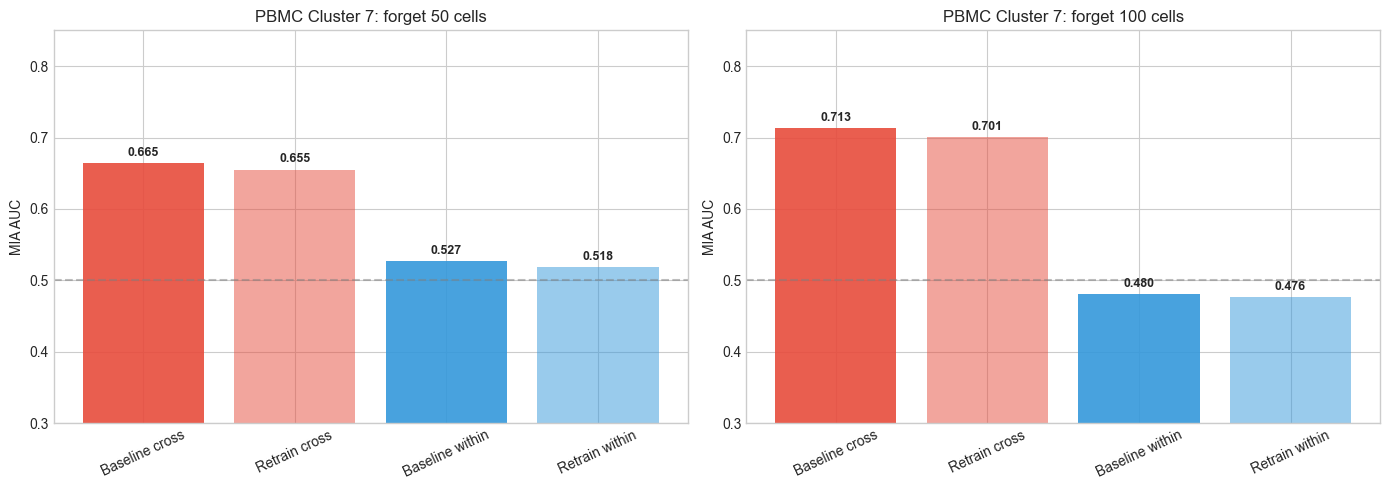

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, n in enumerate([50, 100]):
    key = f'n={n}'
    names = ['Baseline cross', 'Retrain cross', 'Baseline within', 'Retrain within']
    aucs = [pbmc_results[key][f'{m}_{t}']['auc']
            for m, t in [('Baseline','cross'), ('Retrain','cross'),
                         ('Baseline','within'), ('Retrain','within')]]
    colors = ['#e74c3c', '#e74c3c', '#3498db', '#3498db']
    alphas = [0.9, 0.5, 0.9, 0.5]

    bars = axes[i].bar(names, aucs, color=colors)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)
    axes[i].axhline(0.5, color='gray', ls='--', alpha=0.5)
    axes[i].set_ylabel('MIA AUC')
    axes[i].set_title(f'PBMC Cluster 7: forget {n} cells')
    axes[i].set_ylim(0.3, 0.85)
    axes[i].tick_params(axis='x', rotation=25)
    for bar, auc in zip(bars, aucs):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{auc:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pbmc_c7_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
rows = []
for n in [50, 100]:
    key = f'n={n}'
    for mt in ['Baseline_cross', 'Retrain_cross', 'Baseline_within', 'Retrain_within']:
        r = pbmc_results[key][mt]
        rows.append({'Forget': n, 'Model_Matching': mt,
                     'AUC': r['auc'], 'Advantage': r['advantage'],
                     'AUC CI': f"[{r['auc_ci'][0]:.3f}, {r['auc_ci'][1]:.3f}]"})
pd.DataFrame(rows).set_index(['Forget', 'Model_Matching']).style.format(
    {'AUC': '{:.3f}', 'Advantage': '{:.3f}'})

## Tabula Muris Cluster 28

In [8]:
adata_tm = sc.read_h5ad('../data/tabula_muris_processed.h5ad')
X_tm = adata_tm.X.toarray() if hasattr(adata_tm.X, 'toarray') else adata_tm.X
leiden_tm = adata_tm.obs['leiden'].values

with open('../outputs/tabula_muris/split_structured.json') as f:
    split_tm = json.load(f)
train_tm = split_tm['forget_indices'] + split_tm['retain_indices']
unseen_tm = split_tm['unseen_indices']

c28_train = [i for i in train_tm if leiden_tm[i] == '28']
c28_unseen = [i for i in unseen_tm if leiden_tm[i] == '28']

np.random.seed(GLOBAL_SEED)
c28_shuffled = np.random.permutation(c28_train).tolist()
forget_tm_50 = sorted(c28_shuffled[:50])
forget_tm_100 = sorted(c28_shuffled[:100])

baseline_tm, config_tm = load_model('../outputs/tabula_muris/baseline/best_model.pt')
retain_sample_tm = [i for i in train_tm if i not in set(forget_tm_100)][:5000]
retain_z_tm = get_latent(baseline_tm, X_tm[retain_sample_tm], DEVICE)

In [9]:
X_train_tm = X_tm[train_tm]
g2l_tm = {g: l for l, g in enumerate(train_tm)}
excl_50_tm = [g2l_tm[i] for i in forget_tm_50]
excl_100_tm = [g2l_tm[i] for i in forget_tm_100]

ckpt_tm_50 = OUTPUT_DIR / 'tm_retrain_c28_50.pt'
ckpt_tm_100 = OUTPUT_DIR / 'tm_retrain_c28_100.pt'

if ckpt_tm_50.exists():
    retrain_tm_50, _ = load_model(str(ckpt_tm_50))
else:
    retrain_tm_50, _ = train_retrain_model(
        adata_tm, X_train_tm, excl_50_tm, config_tm, DEVICE, seed=GLOBAL_SEED)
    torch.save({'model_state_dict': retrain_tm_50.state_dict(), 'config': config_tm}, ckpt_tm_50)

if ckpt_tm_100.exists():
    retrain_tm_100, _ = load_model(str(ckpt_tm_100))
else:
    retrain_tm_100, _ = train_retrain_model(
        adata_tm, X_train_tm, excl_100_tm, config_tm, DEVICE, seed=GLOBAL_SEED)
    torch.save({'model_state_dict': retrain_tm_100.state_dict(), 'config': config_tm}, ckpt_tm_100)

In [10]:
unseen_z_tm = get_latent(baseline_tm, X_tm[unseen_tm], DEVICE)
nbrs_tm = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(unseen_z_tm)

tm_results = {}
for n_forget, forget_idx, retrain_model in [
    (50, forget_tm_50, retrain_tm_50),
    (100, forget_tm_100, retrain_tm_100),
]:
    key = f'n={n_forget}'
    tm_results[key] = {}

    fz = get_latent(baseline_tm, X_tm[forget_idx], DEVICE)
    dist, idx = nbrs_tm.kneighbors(fz)
    cross_matched = [int(unseen_tm[i]) for i in np.unique(idx.flatten())]

    for model_name, model in [('Baseline', baseline_tm), ('Retrain', retrain_model)]:
        rz = get_latent(model, X_tm[retain_sample_tm], DEVICE)

        f_feats = get_70dim_features(model, X_tm[forget_idx], rz, DEVICE)
        m_feats = get_70dim_features(model, X_tm[cross_matched], rz, DEVICE)
        tm_results[key][f'{model_name}_cross'] = train_fresh_attacker_70dim(
            f_feats, m_feats, DEVICE)

        w_feats = get_70dim_features(model, X_tm[c28_unseen], rz, DEVICE)
        tm_results[key][f'{model_name}_within'] = train_fresh_attacker_70dim(
            f_feats, w_feats, DEVICE)

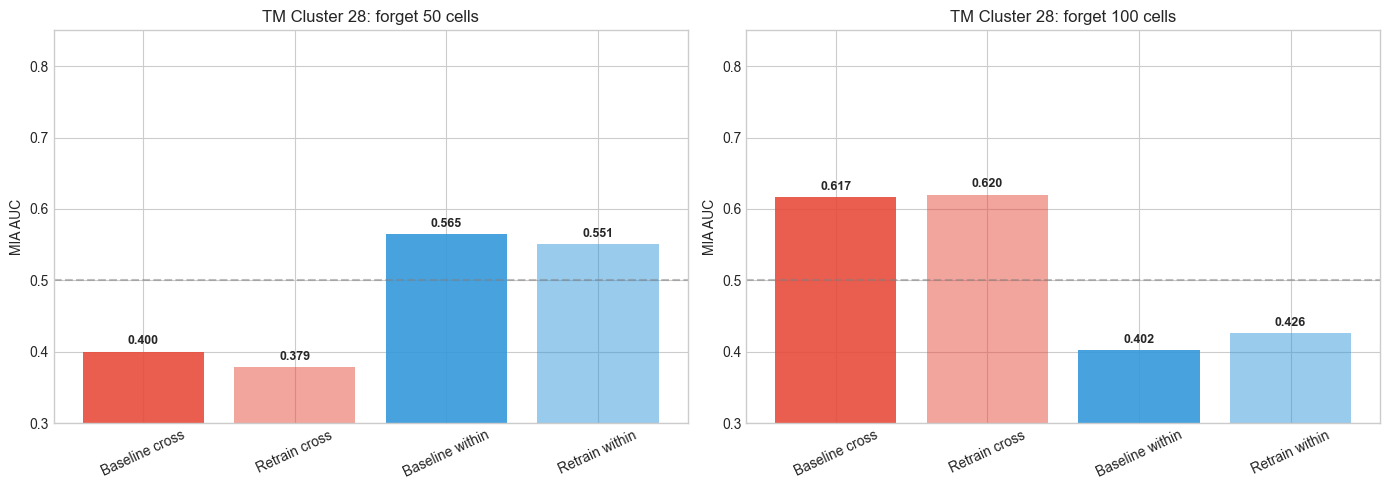

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, n in enumerate([50, 100]):
    key = f'n={n}'
    names = ['Baseline cross', 'Retrain cross', 'Baseline within', 'Retrain within']
    aucs = [tm_results[key][f'{m}_{t}']['auc']
            for m, t in [('Baseline','cross'), ('Retrain','cross'),
                         ('Baseline','within'), ('Retrain','within')]]
    colors = ['#e74c3c', '#e74c3c', '#3498db', '#3498db']
    alphas = [0.9, 0.5, 0.9, 0.5]

    bars = axes[i].bar(names, aucs, color=colors)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)
    axes[i].axhline(0.5, color='gray', ls='--', alpha=0.5)
    axes[i].set_ylabel('MIA AUC')
    axes[i].set_title(f'TM Cluster 28: forget {n} cells')
    axes[i].set_ylim(0.3, 0.85)
    axes[i].tick_params(axis='x', rotation=25)
    for bar, auc in zip(bars, aucs):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{auc:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tm_c28_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
rows = []
for n in [50, 100]:
    key = f'n={n}'
    for mt in ['Baseline_cross', 'Retrain_cross', 'Baseline_within', 'Retrain_within']:
        r = tm_results[key][mt]
        rows.append({'Forget': n, 'Model_Matching': mt,
                     'AUC': r['auc'], 'Advantage': r['advantage'],
                     'AUC CI': f"[{r['auc_ci'][0]:.3f}, {r['auc_ci'][1]:.3f}]"})
pd.DataFrame(rows).set_index(['Forget', 'Model_Matching']).style.format(
    {'AUC': '{:.3f}', 'Advantage': '{:.3f}'})

## Save results

In [13]:
all_results = {
    'pbmc_c7': pbmc_results,
    'tm_c28': tm_results,
    'pbmc_c7_metadata': {
        'cluster': '7', 'cell_type': 'CD14+ monocytes',
        'total': len(c7_train) + len(c7_unseen),
        'train': len(c7_train), 'unseen': len(c7_unseen),
        'forget_sizes': [50, 100],
    },
    'tm_c28_metadata': {
        'cluster': '28',
        'total': len(c28_train) + len(c28_unseen),
        'train': len(c28_train), 'unseen': len(c28_unseen),
        'forget_sizes': [50, 100],
    },
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| PBMC cluster 7 results | `outputs/larger_cluster_eval/pbmc_c7_results.png` |
| TM cluster 28 results | `outputs/larger_cluster_eval/tm_c28_results.png` |
| Retrain checkpoints | `outputs/larger_cluster_eval/pbmc_retrain_c7_{50,100}.pt` |
| TM retrain checkpoints | `outputs/larger_cluster_eval/tm_retrain_c28_{50,100}.pt` |
| Results JSON | `outputs/larger_cluster_eval/results.json` |

Uses 70-dim canonical features (v1 + kNN distance to retain, k=5).
Bootstrap CIs computed via attacker_eval.compute_confidence_interval.